# Using Open-Source Software to Perform Scattering Calculations
<br>
<br>
<center>Homework Assignment #1 <br>
Mie Scattering <br>
METR/ECE 5683 <br>
Due Friday, February 13th at 11:59 PM <br>
100 pts</center>


This assignment provides a hands-on tutorial of Mie scattering applied to hydrometeors. We will use the miepython library developed by Scott Prahl to compute radar cross sections using Mie codes (e.g., solving the infinite series introduced in class). Some of the tutorial material was adapted from material from Scott Prahl and the miepython library. The miepython document is available <a href="https://miepython.readthedocs.io/en/latest/">here</a>.

*If miepython is not installed, uncomment the following cell (i.e., delete the #) and run (shift-enter)*

In [1]:
import importlib.resources
import numpy as np
import matplotlib.pyplot as plt
import sys, os

if sys.platform == "emscripten":
    import piplite

    await piplite.install("miepython", deps=False)
    os.environ["MIEPYTHON_USE_JIT"] = "0"  # jupyterlite cannot use numba

import miepython

## Index of Refraction and Size Parameter

When a monochromatic plane wave is incident on a sphere, it scatters and absorbs light depending on the properties of the light and sphere.  If the sphere is in a vacuum, then the complex index of refraction of the sphere is

$$
m_\mathrm{vac}= m_\mathrm{re}- j\,m_\mathrm{im}
$$

The factor $m_\mathrm{im}=\kappa$ is the *index of absorption* or the *index of attenuation*.  

## Size Parameters

### Size Parameter $x$
The sphere size relative to the wavelength is called the size
parameter $x$
$$
x = 2\pi {r/\lambda}
$$
where $r$ is the radius of the sphere.

## Complex refractive index calculation for water

The function, complex_perm_water, can be used to calculate the complex refractive index (m) and complex relative permittivity ($\epsilon_{r}$) for water using equations from Cole and Cole (1941) and Ray (1974). The function requires two argument, wavelength (in cm) and temperature (in degrees Celsius).

In [2]:
#Complex relative permittivity calculation for water
#Based on Cole and Cole 1941 and Ray 1972
#Inputs: lam (cm) and t_w (degrees C)
#Outputs: Complex dielectric factor (ep) and refractive index (m)
def complex_perm_water(lam,t_w):
	import numpy as np
	es=78.54*(1-4.579e-3*(t_w-25)+1.19e-5*(t_w-25)**2-2.8e-8*(t_w-25)**3);
	einf=5.27137+0.021647*t_w-0.00131198*t_w**2;
	alp=-16.8129/(t_w+273)+0.0609265;
	lam_s=0.00033836*np.exp(2513.98/(t_w+273));
	sigma=12.5664e8;

	#Calculate Real part of the dielectric factor for water
	ep_rw=einf+((es-einf)*(1+(lam_s/lam)**(1-alp)*np.sin(alp*np.pi/2)))/(1+2*(lam_s/lam)**(1-alp)*np.sin(alp*np.pi/2)+(lam_s/lam)**(2*(1-alp)));

	#Calculate Imaginary part of the dielectric factor for water
	ep_iw=((es-einf)*(lam_s/lam)**(1-alp)*np.cos(alp*np.pi/2))/(1+2*(lam_s/lam)**(1-alp)*np.sin(alp*np.pi/2)+(lam_s/lam)**(2*(1-alp)))+sigma*lam/(18.8496*10**10);

	#Calculate refractive index (real and imaginary components nr and ni)
	nr_water=(1/2*ep_rw + 1/2*(ep_iw**2 + ep_rw**2)**(1/2))**(1/2);
	ni_water=(2*(ep_rw/2 + (ep_iw**2 + ep_rw**2)**(1/2)/2)**(3/2) - 2*ep_rw*(ep_rw/2 + (ep_iw**2 + ep_rw**2)**(1/2)/2)**(1/2))/ep_iw;

	ep = ep_rw - ep_iw*1j
	m = nr_water - ni_water*1j
	return ep, m

# Question 1: Calculate Cross Sections using Mie function



Use the miepython.mie function to calculate backscatter, scattering, and extinction cross sections ($\sigma_{b}$) for rain drops with a diameter range of 0.1 to 10 mm at S band (107-mm wavelength), X-band (31-mm wavelength), and W-band (3-mm wavelength). Assume the temperature is 20 degrees Celsius. Convert the cross sections to units of mm$^{2}$.

The mie python function requires the complex refractive index (m) and size parameter (x) as arguments, and it returns the extinction ($Q_{ext}$), scattering ($Q_{sca}$), and backscattering efficiences ($Q_{back}$), and the average cosine of the scattering function (we won't use this parameter).

The structure of the mie function with the arguments and returned variables is:
```python
[qext, qsca, qback, g] = miepython.efficiencies_mx(m,x)
```

Recall that the efficiences are the radar cross section divided by the scatterer's geometric area. For example, the extinction cross section is related to the extinction efficiency as follows:

$Q_{ext} = \frac{\sigma_{ext}}{\pi D^2/4}$

In [3]:
wlens = [107., 31., 3.]
D = np.arange(0.1, 10.1, 0.1)
sext, ssca, sback = [np.empty((D.size, len(wlens))) for _ in range(3)]
for jwlen in range(len(wlens)):
    wlen = wlens[jwlen]
    # complex refractive index
    _, m = complex_perm_water(wlen/10, 20)
    for jD in range(D.size):
        # radius of rain drop
        r = D[jD] / 2
        # size parameter
        x = (2 * np.pi * r) / wlen

        # cross section effecienes
        qext, qsca, qback, _ = miepython.efficiencies_mx(m, x)
        
        # extinction cross section
        sext[jD, jwlen] = (qext * np.pi * D[jD]**2) / 4
        # scattering cross section
        ssca[jD, jwlen] = (qsca * np.pi * D[jD]**2) / 4
        # backscatter cross section
        sback[jD, jwlen] = (qback * np.pi * D[jD]**2) / 4

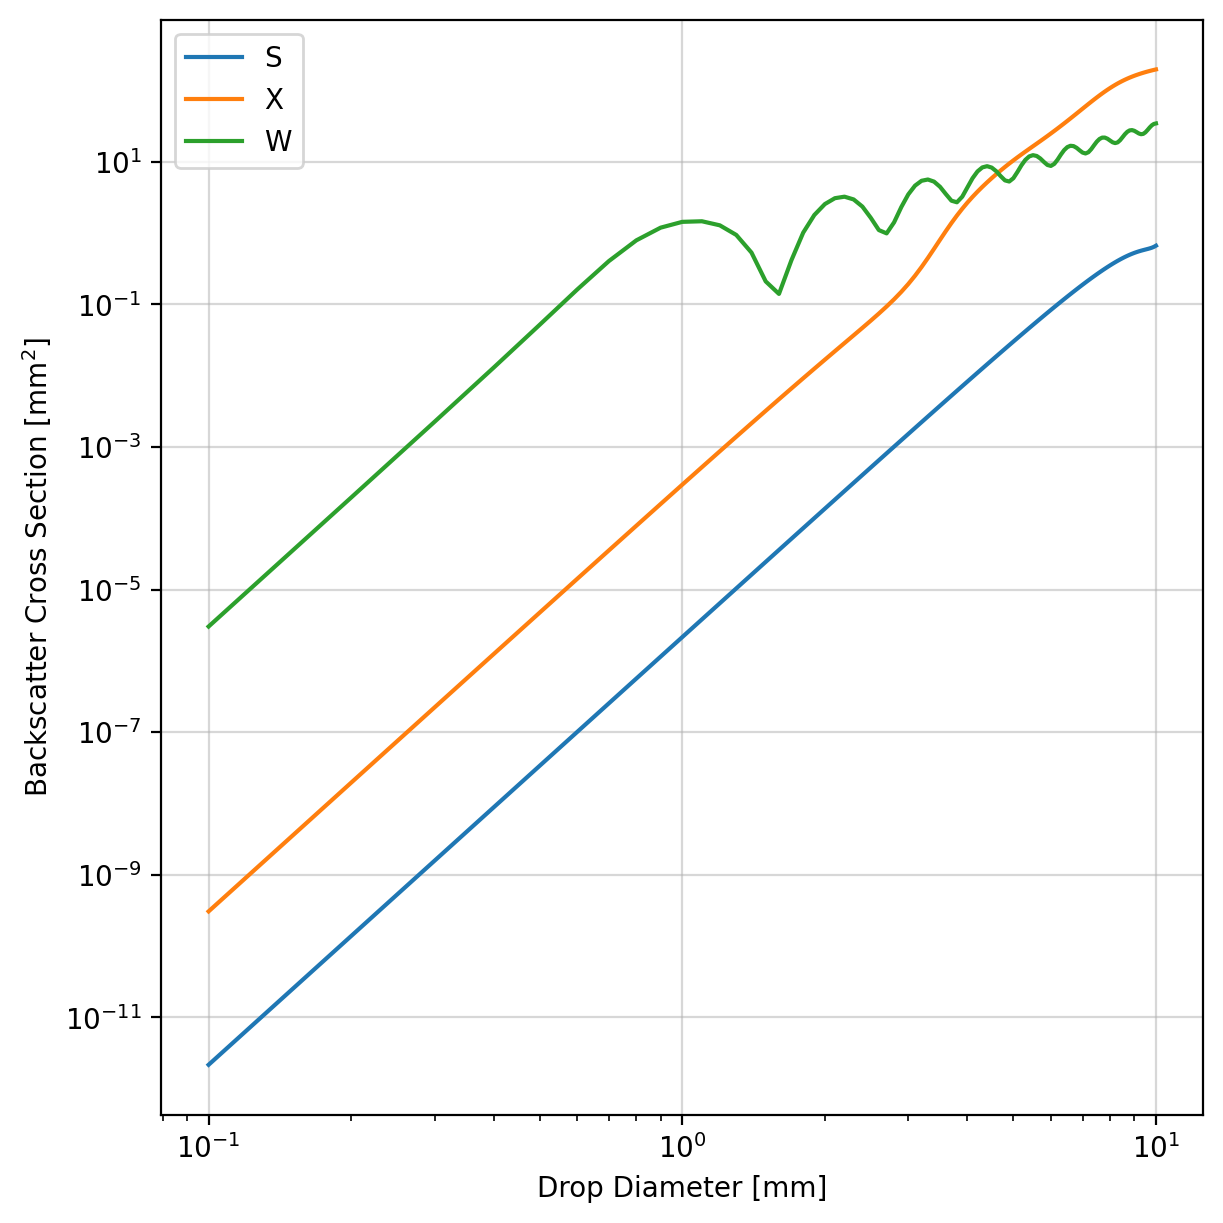

In [4]:
fig, ax = plt.subplots(figsize=(6,6),
                       constrained_layout=True,
                       dpi=200)

ax.plot(D, sback[:,0], label='S')
ax.plot(D, sback[:,1], label='X')
ax.plot(D, sback[:,2], label='W')

ax.set_xscale('log')
ax.set_xlabel("Drop Diameter [mm]")
ax.set_yscale('log')
ax.set_ylabel("Backscatter Cross Section [mm$^2$]")


ax.grid(alpha=0.5)
ax.legend()

# 2. Plotting the Backscatter Cross Section: Rayleigh vs. Mie Scattering

a) Calculate the backscatter cross sections at S, X, and W bands assuming Rayleigh scattering. Calculate |Km|^2 using the complex refractive index.

b) Using a log scaling for both the x and y-axes (loglog function), create a plot with the backscatter cross section from the Mie and Rayleigh scattering calculations for all three wavelengths (6 lines total). To make the plot easier to interpret, consider using the same line color for each wavelength, but use a different line style to differentiate Rayleigh and Mie scattering. Add a legend so the lines can be easily identified.

In [5]:
sback_ray = np.empty((D.size, len(wlens)))
for jwlen in range(len(wlens)):
    wlen = wlens[jwlen]
    # complex refractive index
    ep, m = complex_perm_water(wlen/10, 20)
    Km = (m**2 - 1) / (m**2 + 2)
    for jD in range(D.size):
        sback_ray[jD, jwlen] = (np.pi**5 / wlen**4) * np.abs(Km)**2 * D[jD]**6

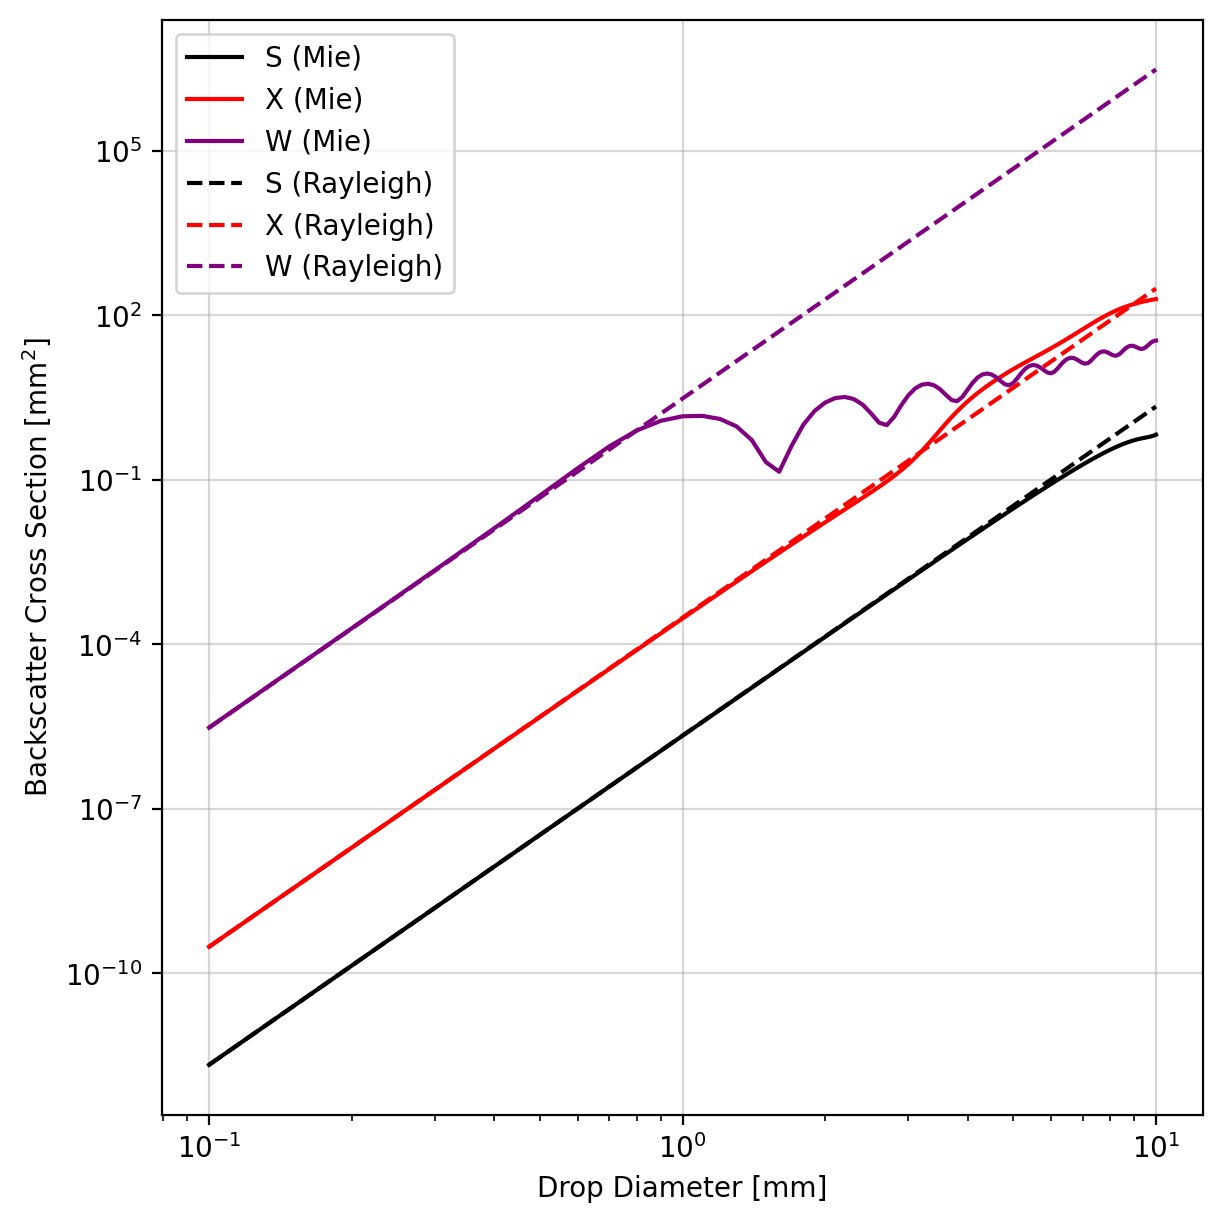

In [6]:
fig, ax = plt.subplots(figsize=(6,6),
                       constrained_layout=True,
                       dpi=200)

# mie
ax.plot(D, sback[:,0], label='S (Mie)', c='black')
ax.plot(D, sback[:,1], label='X (Mie)', c='red')
ax.plot(D, sback[:,2], label='W (Mie)', c='purple')
# rayleigh
ax.plot(D, sback_ray[:,0], label='S (Rayleigh)', ls='--', c='black')
ax.plot(D, sback_ray[:,1], label='X (Rayleigh)', ls='--', c='red')
ax.plot(D, sback_ray[:,2], label='W (Rayleigh)', ls='--', c='purple')

ax.set_xscale('log')
ax.set_xlabel("Drop Diameter [mm]")
ax.set_yscale('log')
ax.set_ylabel("Backscatter Cross Section [mm$^2$]")


ax.grid(alpha=0.5)
ax.legend()

# 3) Scattering, Absorption, and Extinction Cross Sections

a) Plot the extinction cross section for all three wavelengths using a log scaling for both the x and y-axes (loglog function). Include a legend on the plot so the lines can be easily identified. <br>
<br>
b) Plot the scattering and absorption cross sections using the formatting guidelines from a), except include them on the same plot with all wavelengths (6 lines total).

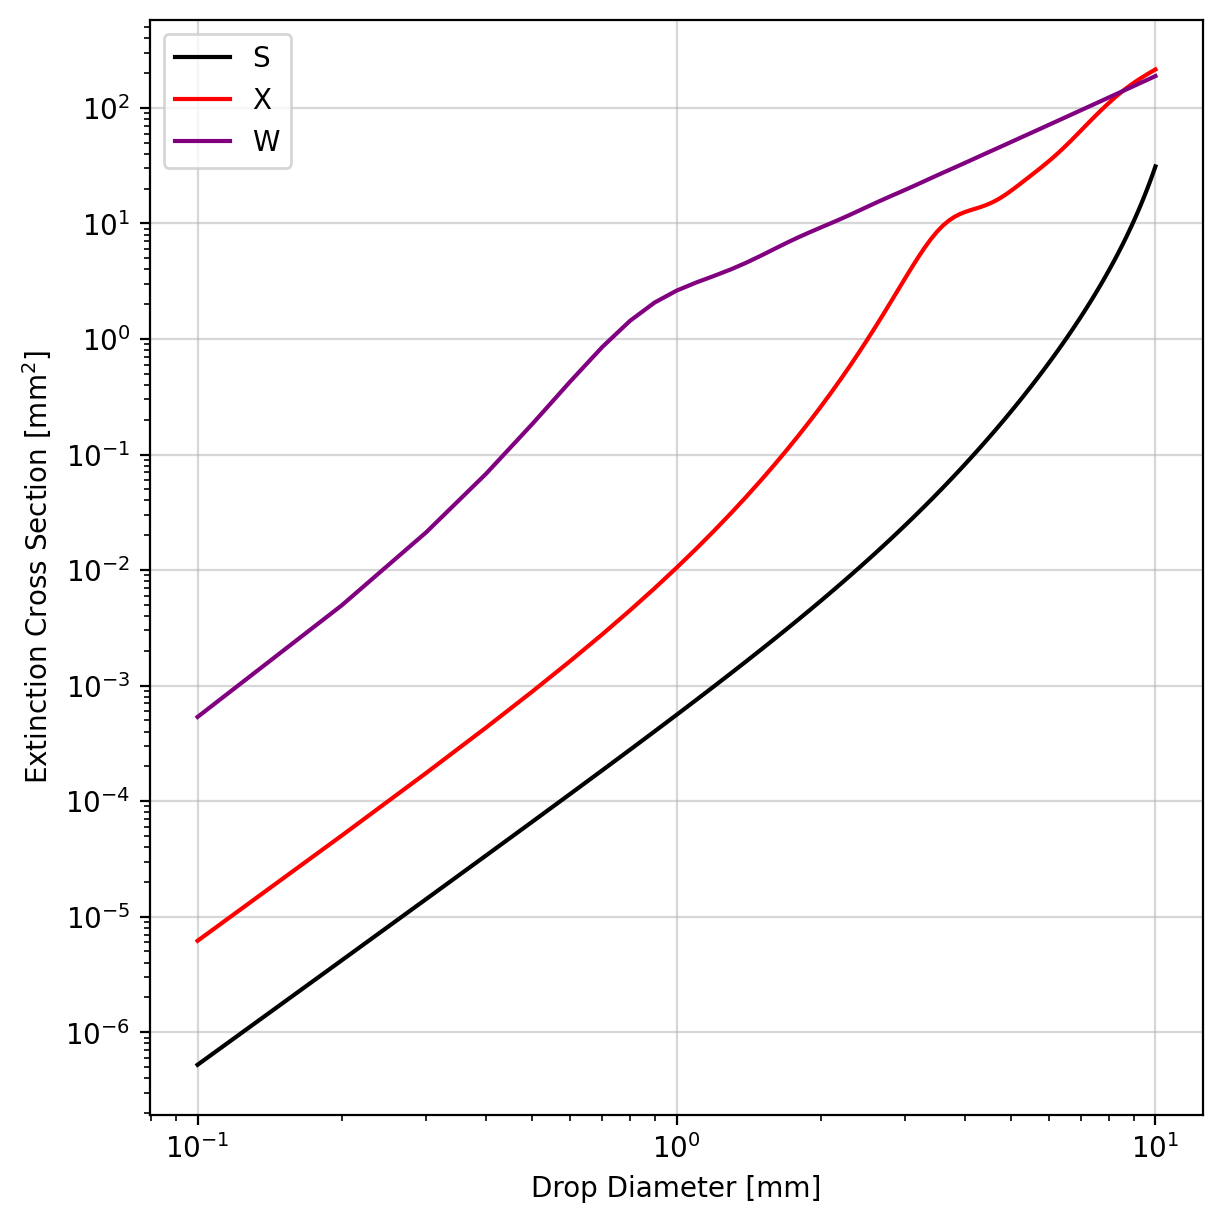

In [7]:
fig, ax = plt.subplots(figsize=(6,6),
                       constrained_layout=True,
                       dpi=200)

ax.plot(D, sext[:,0], label='S', c='black')
ax.plot(D, sext[:,1], label='X', c='red')
ax.plot(D, sext[:,2], label='W', c='purple')

ax.set_xscale('log')
ax.set_xlabel("Drop Diameter [mm]")
ax.set_yscale('log')
ax.set_ylabel("Extinction Cross Section [mm$^2$]")


ax.grid(alpha=0.5)
ax.legend()

In [8]:
sabs = sext - ssca

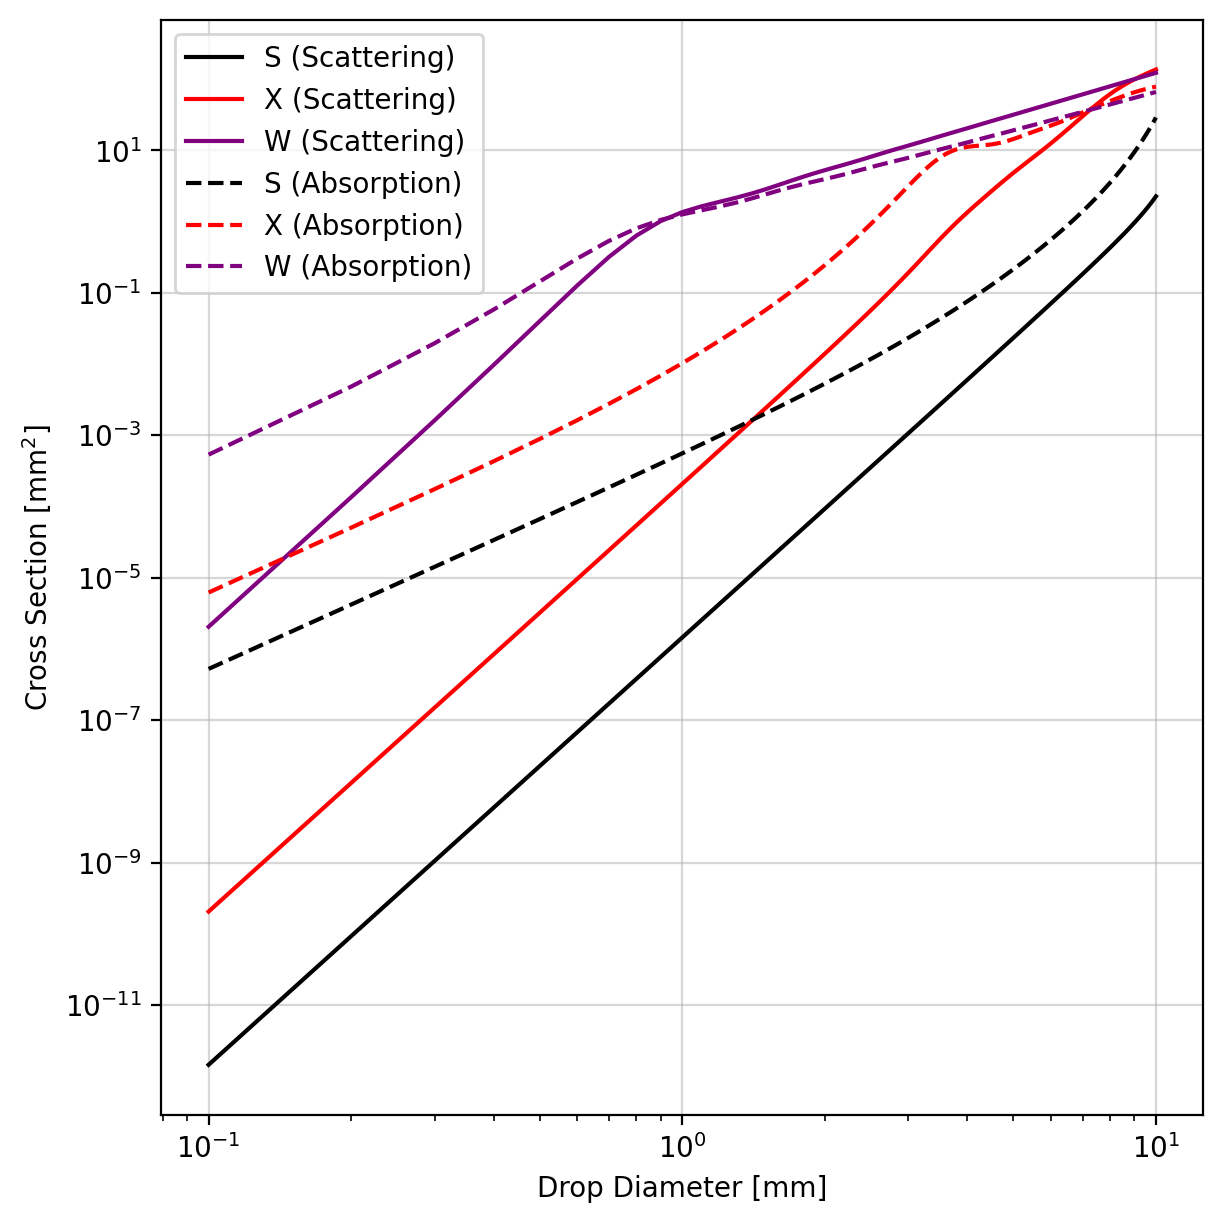

In [9]:
fig, ax = plt.subplots(figsize=(6,6),
                       constrained_layout=True,
                       dpi=200)

# scattering
ax.plot(D, ssca[:,0], label='S (Scattering)', c='black')
ax.plot(D, ssca[:,1], label='X (Scattering)', c='red')
ax.plot(D, ssca[:,2], label='W (Scattering)', c='purple')
# absorption
ax.plot(D, sabs[:,0], label='S (Absorption)', c='black', ls='--')
ax.plot(D, sabs[:,1], label='X (Absorption)', c='red', ls='--')
ax.plot(D, sabs[:,2], label='W (Absorption)', c='purple', ls='--')

ax.set_xscale('log')
ax.set_xlabel("Drop Diameter [mm]")
ax.set_yscale('log')
ax.set_ylabel("Cross Section [mm$^2$]")


ax.grid(alpha=0.5)
ax.legend()

# 4) Backscatter Cross Section and Equivalent Reflectivity Factor

While the backscatter cross section is a useful way to understand the backscattered power, we really care about equivalent reflectivity factor ($Z_{e}$) that is shown on a radar image.

Recall that:

$\eta$ = $\frac{\pi^5}{\lambda^4}|K_{m}|^2 Z_{e}$

and

$\eta$ = $\frac{\sum_{i=0}^{N} \sigma_{bi}}{V}$

Using the equations above and assuming there is one drop per cubic meter, calculate the equilvalent reflectivity factor ($Z_{e}$, dBZ) as a function of drop diameter.

Plot $Z_{e}$ as a function of diameter for all three wavelengths.

In [10]:
eta = sback * 1e-6
Ze = np.empty_like(sback)
for jwlen in range(len(wlens)):
    wlen = wlens[jwlen]
    # complex refractive index
    ep, m = complex_perm_water(wlen/10, 20)
    Km = (m**2 - 1) / (m**2 + 2)
    # reflectivity factor
    Ze[:,jwlen] = (eta[:,jwlen] * wlen**4) / (np.pi**5 * np.abs(Km)**2)

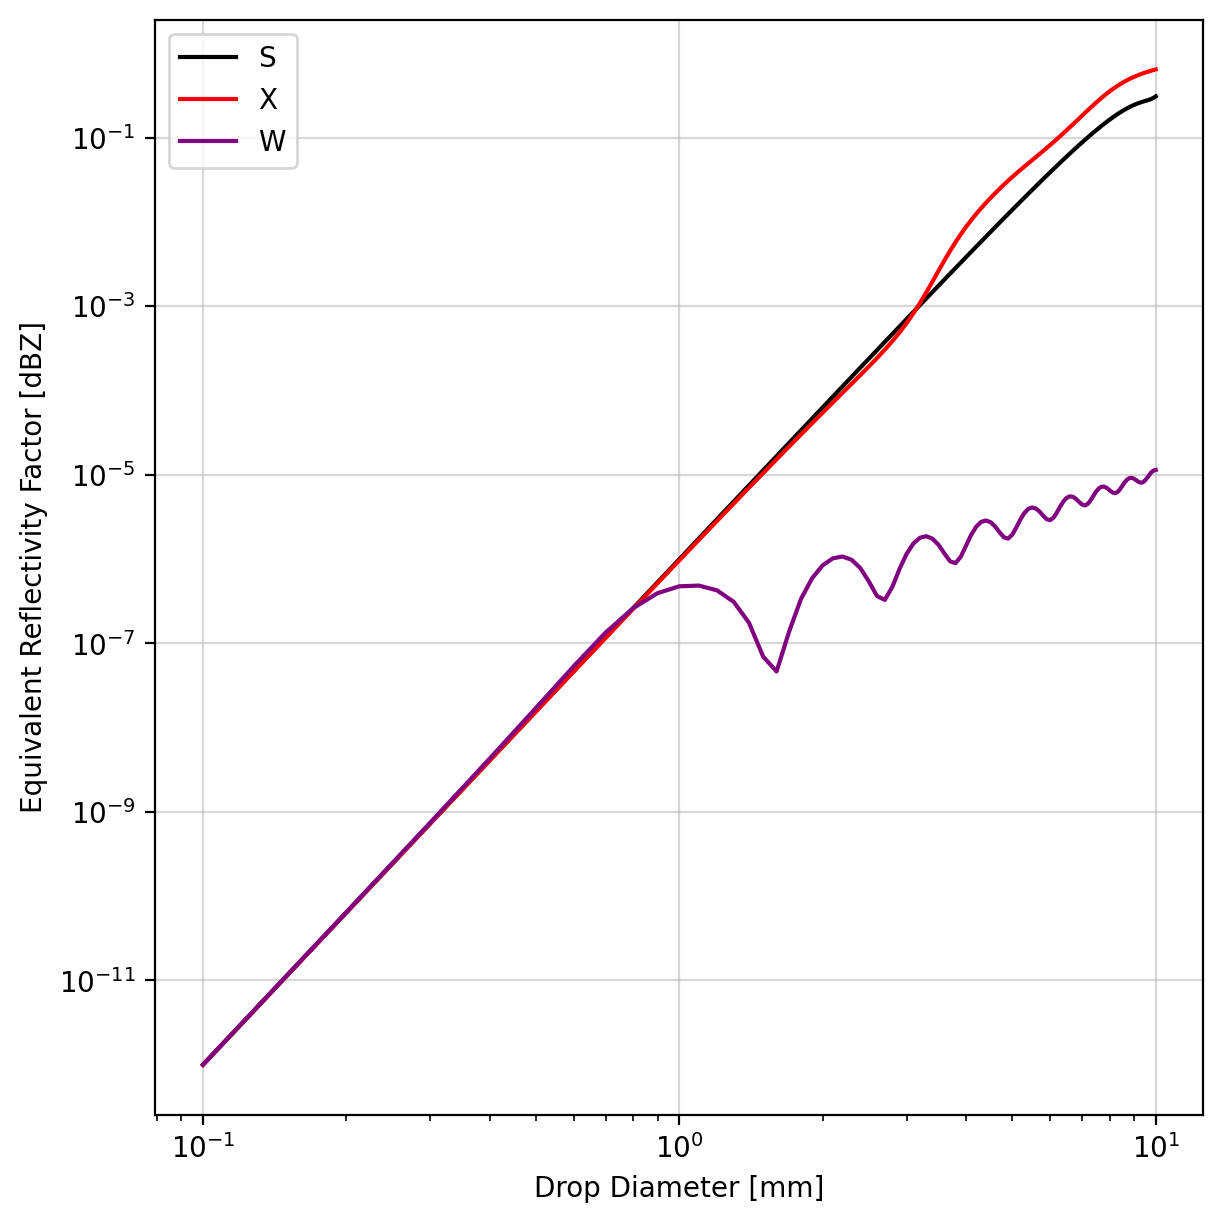

In [11]:
fig, ax = plt.subplots(figsize=(6,6),
                       constrained_layout=True,
                       dpi=200)

ax.plot(D, Ze[:,0], label='S', c='black')
ax.plot(D, Ze[:,1], label='X', c='red')
ax.plot(D, Ze[:,2], label='W', c='purple')

ax.set_xscale('log')
ax.set_xlabel("Drop Diameter [mm]")
ax.set_yscale('log')
ax.set_ylabel("Equivalent Reflectivity Factor [dBZ]")


ax.grid(alpha=0.5)
ax.legend()

# 5) Self-Exploration: Your Choice!

Choose one of the following or do some of your own experiments to try different sizes, refractive indices, etc.! You can also make plots of scattering efficiencies as a function of scattering angle using the miepython package.

a) Calculate the backscatter cross section of hailstones for diameters between 0 and 70 mm at S, C, and X bands, and plot the result. For the complex refractive indices, use m=1.780-0.000j for each wavelength.

b) Calculate the backscatter cross section of rain drops from 0 to 10 mm at S and C bands for different temperatures (0, 10, 20 degrees C).

c) Try your own experiment!

Make sure you turn in the relevant plot for either a), b), or your own plot from c).

## b) Backscatter Cross Sections for Different Temperatures

In [12]:
wlens = [107., 50.]
temps = [0, 10, 20]
D = np.arange(0.1, 10.1, 0.1)
sback = np.empty((D.size, len(wlens), len(temps)))
for jwlen in range(len(wlens)):
    for jt in range(len(temps)):
        wlen = wlens[jwlen]
        temp = temps[jt]
        # complex refractive index
        _, m = complex_perm_water(wlen/10, temp)
        for jD in range(D.size):
            # radius of rain drop
            r = D[jD] / 2
            # size parameter
            x = (2 * np.pi * r) / wlen

            # cross section effecienes
            _, _, qback, _ = miepython.efficiencies_mx(m, x)
            
            # backscatter cross section
            sback[jD, jwlen, jt] = (qback * np.pi * D[jD]**2) / 4

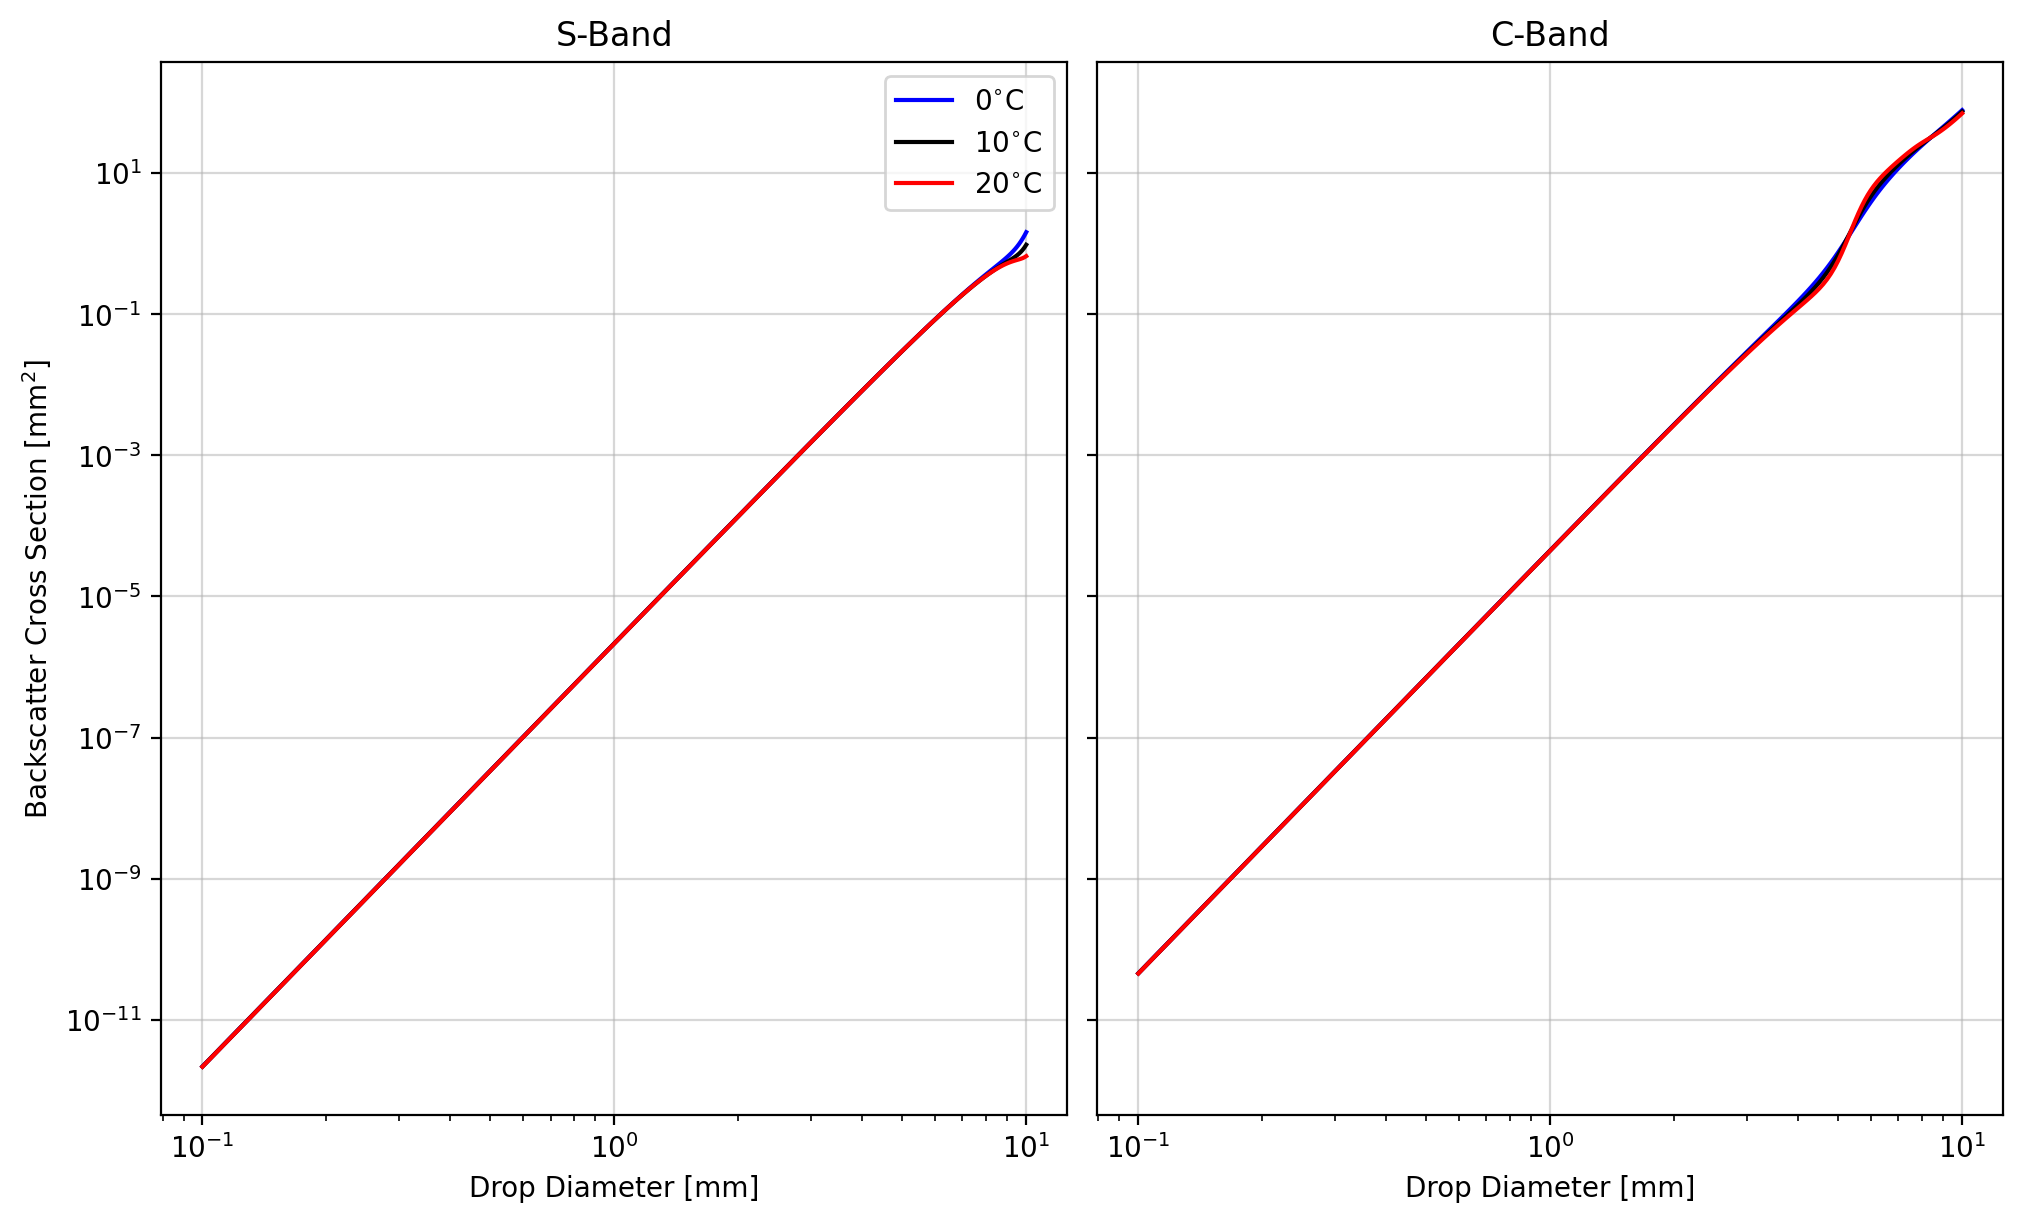

In [13]:
fig, axs = plt.subplots(figsize=(10,6),
                       constrained_layout=True,
                       dpi=200,
                       ncols=2,
                       sharey=True)

# s band
ax = axs[0]
ax.plot(D, sback[:,0,0], label='0$^{\\circ}$C', c='blue')
ax.plot(D, sback[:,0,1], label='10$^{\\circ}$C', c='black')
ax.plot(D, sback[:,0,2], label='20$^{\\circ}$C', c='red')
ax.set_ylabel("Backscatter Cross Section [mm$^2$]")
ax.set_title("S-Band")
ax.legend()
# c band
ax = axs[1]
ax.plot(D, sback[:,1,0], label='0$^{\\circ}$C', c='blue')
ax.plot(D, sback[:,1,1], label='10$^{\\circ}$C', c='black')
ax.plot(D, sback[:,1,2], label='20$^{\\circ}$C', c='red')
ax.set_title("C-Band")

for ax in axs:
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel("Drop Diameter [mm]")
    ax.grid(alpha=0.5)